# Analisis descriptivo y exploratorio del dataset interno

## Carga de datos y librerias

In [15]:
# Build an EDA (Exploratory Data Analysis) for the dataset data/data/raw/inventario_subastas_simon.csv
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import sys
from pathlib import Path

# Agregar el directorio raíz del proyecto al sys.path
BASE_DIR = Path().resolve().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

import src.data_processing as dp

df_raw = pandas.read_csv('/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/raw/inventario_subastas_simon.csv')

## Diagnóstico de Salud de los Datos Crudos & Perfilado Inicial

In [2]:
print("Valores nulos por columna:")
print(df_raw.isnull().sum())
print("\nNúmero de filas duplicadas:")
print(df_raw.duplicated().sum())

Valores nulos por columna:
ID_Vehiculo                0
Marca                      0
Linea                      0
Modelo                     0
Kilometraje                0
Estado_Vehiculo            0
Costo_Adquisicion_COP      0
Valor_Fasecolda_COP        0
Dias_en_Inventario         0
Canal_Asignado             0
Precio_Reserva_COP         0
Precio_Final_Venta_COP     0
Estado_Subasta             0
ID_Comprador              97
Tipo_Comprador            97
dtype: int64

Número de filas duplicadas:
0


In [3]:
print("\nResumen estadístico del dataframe crudo:")
df_raw.describe()


Resumen estadístico del dataframe crudo:


,Modelo,Kilometraje,Costo_Adquisicion_COP,Valor_Fasecolda_COP,Dias_en_Inventario,Precio_Reserva_COP,Precio_Final_Venta_COP
count,350.000000,350.000000,3.500000e+02,3.500000e+02,350.000000,3.500000e+02,3.500000e+02
mean,2020.840000,94306.545714,6.679057e+07,8.341743e+07,48.685714,7.164057e+07,5.733286e+07
std,1.680019,35951.606311,2.890665e+07,3.586153e+07,37.376173,3.120524e+07,4.535864e+07
min,2018.000000,25122.000000,2.720000e+07,3.520000e+07,15.000000,2.940000e+07,0.000000e+00
25%,2020.000000,67833.750000,4.650000e+07,5.725000e+07,15.000000,4.967500e+07,0.000000e+00
50%,2021.000000,89998.500000,6.330000e+07,7.745000e+07,45.000000,6.755000e+07,6.100000e+07
75%,2022.000000,118544.000000,7.682500e+07,9.672500e+07,60.000000,8.155000e+07,8.397500e+07
max,2024.000000,198423.000000,1.781000e+08,2.104000e+08,180.000000,1.977000e+08,2.377000e+08


### Limpieza de datos, construcción de indices y enriquecimiento con datos externos.
Usaremos las funciones modulares escritas en src/data_processing.py para estas tareas.

In [4]:
df = dp.cargar_y_procesar_datos('/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/raw/inventario_subastas_simon.csv')
df_enriched = dp.enriquecer_con_fuentes_externas(df, '/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/external/ref_mercado_runt_fasecolda.csv')

In [5]:
df.head()

,ID_Vehiculo,Marca,Linea,Modelo,Kilometraje,Estado_Vehiculo,Costo_Adquisicion_COP,Valor_Fasecolda_COP,Dias_en_Inventario,Canal_Asignado,...,ID_Comprador,Tipo_Comprador,Win_Rate_Flag,Porcentaje_Recuperacion,Spread_Puja_COP,Ratio_Costo_Fasecolda,Ratio_Reserva_Fasecolda,Categoria_Fasecolda,Tramo_Aging,Holding_Cost_COP
0,SIM-1001,Toyota,Hilux,2022,79036,Excelente,147800000.0,175000000.0,30,Subasta Virtual,...,CLI-153,Financiera Partner,1,119.688769,21200000.0,0.844571,0.889714,Fair Value,<=30 días,2.217000e+06
1,SIM-1002,Hyundai,Tucson,2024,40054,Excelente,93000000.0,105800000.0,45,Subasta Virtual,...,CLI-116,Dealer / Reventa,1,106.236559,-900000.0,0.879017,0.942344,Overpriced,31-60 días,2.100327e+06
2,SIM-1003,Renault,Duster,2020,139075,Bueno,58100000.0,73100000.0,45,Subasta Virtual,...,CLI-126,Dealer / Reventa,1,119.449225,4700000.0,0.794802,0.885089,Fair Value,31-60 días,1.312140e+06
3,SIM-1004,Renault,Kwid,2019,159820,Bueno,33000000.0,40400000.0,15,Subasta Virtual,...,CLI-104,Dealer / Reventa,1,113.030303,1100000.0,0.816832,0.896040,Fair Value,<=30 días,2.465788e+05
4,SIM-1005,Chevrolet,Tracker,2022,79090,Excelente,75300000.0,87200000.0,120,Subasta Virtual,...,CLI-118,Empresa Flotilla,1,109.960159,5700000.0,0.863532,0.884174,Overpriced,>90 días,4.620675e+06


## Análisis de Antigüedad y Dinámica de Inventario

### Distribución de días en el inventario
El 50% central de los vehículos se mantienen en el inventario entre 15 a 60 días. Es decir, hay un 25% que ha estado en el inventario por más de 2 meses, llegando a un máximo de 6 meses.

<Axes: title={'center': 'Boxplot de Días en Inventario'}>

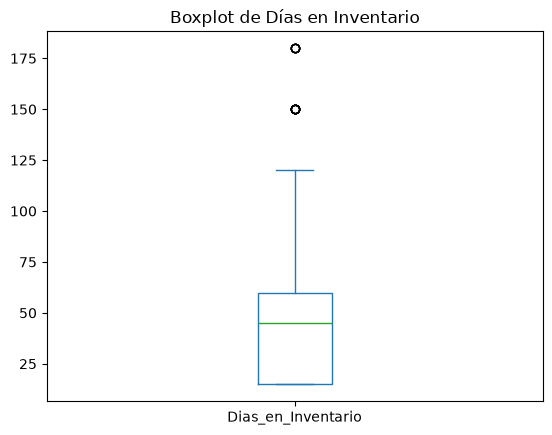

In [6]:
df['Dias_en_Inventario'].plot(kind='box', title='Boxplot de Días en Inventario')

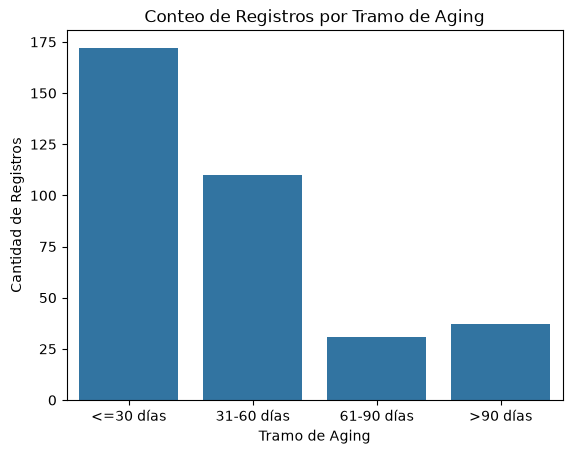

In [7]:
sns.countplot(data=df, x='Tramo_Aging')
plt.title('Conteo de Registros por Tramo de Aging')
plt.xlabel('Tramo de Aging')
plt.ylabel('Cantidad de Registros')
plt.show()

In [8]:
print(df['Tramo_Aging'].value_counts())

Tramo_Aging
<=30 días     172
31-60 días    110
>90 días       37
61-90 días     31
Name: count, dtype: int64


In [9]:
37+31

68

En numeros absolutos, hay 68 vehículos que estuvieron más de 2 meses en el inventario. En particular, 37 vehículos que estuvieron más de 3 meses, estos representan los más críticos y que necesitan/necesitaron de reasignación o liquidación.

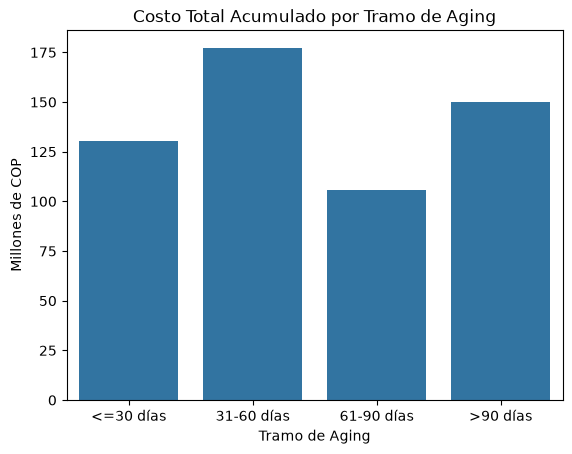

In [10]:
df['Holding_Cost_Millones'] = df['Holding_Cost_COP'] / 1_000_000
sns.barplot(data=df, x='Tramo_Aging', y='Holding_Cost_Millones', estimator='sum', errorbar=None)
plt.title('Costo Total Acumulado por Tramo de Aging')
plt.xlabel('Tramo de Aging')
plt.ylabel('Millones de COP')
plt.show()

Esto se traduce a que el costo del 25% de vehículos que más se tiempo están en el inventario producen el mismo costo que el 75% restante.

## Conversión de Ventas y Análisis de Elasticidad
Evaluamos cuál es el porcentaje de vehículos sin adjudicación, el cuál es casi el 30% de los vehículos en la base de datos.

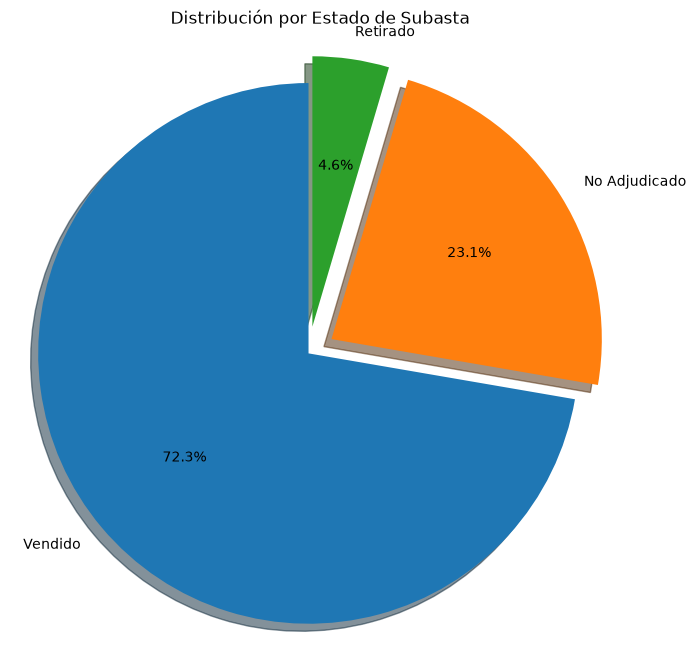

In [12]:
conteo_estado = df["Estado_Subasta"].value_counts()

categorias_resaltadas = {"No Adjudicado", "Retirado"}
explode = [
    0.1 if categoria in categorias_resaltadas else 0
    for categoria in conteo_estado.index
]

plt.figure(figsize=(8, 8))
plt.pie(
    conteo_estado.values,
    labels=conteo_estado.index,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Distribución por Estado de Subasta")
plt.axis("equal")
plt.show()

Hacemos una prueba estadística para comprobar si hay diferencias entre la adjudicación y los días en el inventario, sin embargo no hay diferencias.

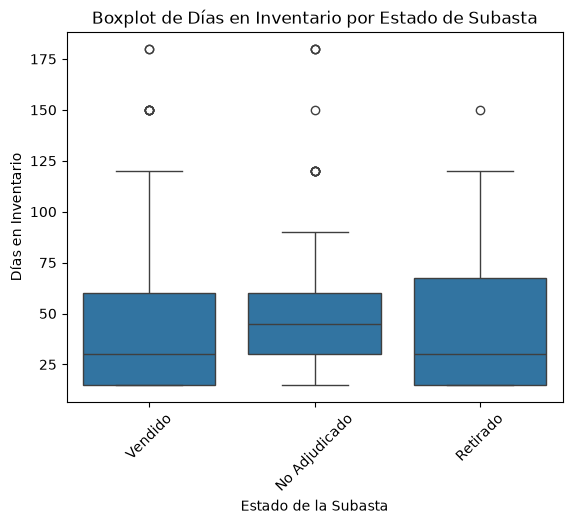

In [13]:
sns.boxplot(data=df, x='Estado_Subasta', y='Dias_en_Inventario')

plt.title('Boxplot de Días en Inventario por Estado de Subasta')
plt.xlabel('Estado de la Subasta')
plt.ylabel('Días en Inventario')
plt.xticks(rotation=45)

plt.show()

In [18]:
grupos = [datos['Dias_en_Inventario'].dropna() for estado, datos in df.groupby('Estado_Subasta')]

stat, p_value = stats.kruskal(*grupos)

print(f"Estadístico de prueba: {stat:.4f}")
print(f"Valor p (p-value): {p_value:}")

Estadístico de prueba: 4.2344
Valor p (p-value): 0.12036638316640172


## Variables de Negocio (RUNT, Marcas y Segmentos)
Usamos las variables externas para identificar patrones. En primer lugar, evaluamos si hay relación entre la demanda de mercado obtenida del RUNT con el estado de adjudicación de los vehículos en el inventario. Con la prueba estadística comprobamos que sí están relacionadas.

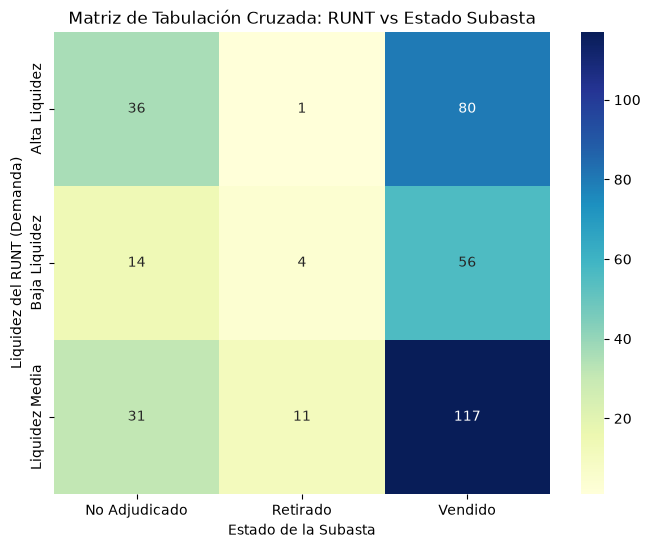

In [23]:
matriz_grafico = pandas.crosstab(df_enriched['Demanda_Mercado_RUNT'], df_enriched['Estado_Subasta'])

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_grafico, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Matriz de Tabulación Cruzada: RUNT vs Estado Subasta')
plt.xlabel('Estado de la Subasta')
plt.ylabel('Liquidez del RUNT (Demanda)')
plt.show()


In [24]:
chi2, p, dof, expected = stats.chi2_contingency(matriz_grafico)
print(f"Valor p de la prueba Chi-cuadrado: {p}")

Valor p de la prueba Chi-cuadrado: 0.034345442878659524


### Alertas de riesgo
Con el siguiente gráfico podemos encontrar vehículos que concentran el mayor capital en riesgo. Son aquellos que se encuentran en la sección I (rojo). Estos vehículos acumulan mayor capital y mayor cantidad de tiempo en el inventario, generando más holding cost.

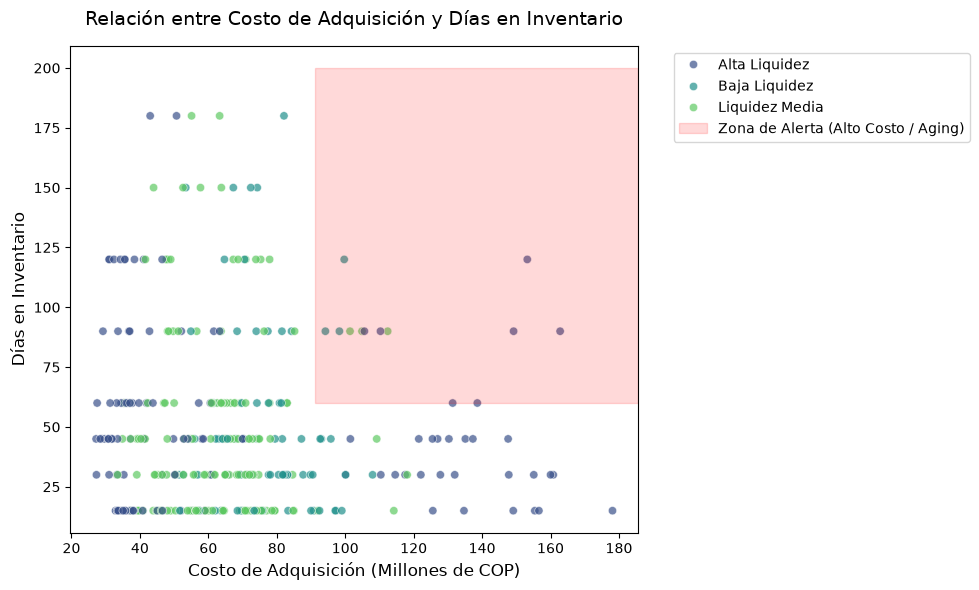

In [31]:
df_enriched['Costo_Adquisicion_Millones'] = df_enriched['Costo_Adquisicion_COP'] / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_enriched, 
    x='Costo_Adquisicion_Millones', 
    y='Dias_en_Inventario', 
    hue='Demanda_Mercado_RUNT',  
    palette='viridis',           
    alpha=0.7,
    ax=ax                 
)

x_min, x_max = 80, df['Costo_Adquisicion_Millones'].max()
y_min, y_max = 60, 200

ax.axhspan(
    ymin=y_min, ymax=y_max, 
    xmin=(x_min / ax.get_xlim()[1]), xmax=1, # Convierte los valores de X a la escala interna (0 a 1) del plano
    color='red', 
    alpha=0.15, # Transparencia baja para que no tape los puntos del fondo
    label='Zona de Alerta (Alto Costo / Aging)'
)

plt.title('Relación entre Costo de Adquisición y Días en Inventario', fontsize=14, pad=15)
plt.xlabel('Costo de Adquisición (Millones de COP)', fontsize=12)
plt.ylabel('Días en Inventario', fontsize=12)
plt.legend(title='Demanda Mercado RUNT', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

A continuación, los vehículos por marca en el tramo de aging más longevo del inventario. Chevrolet, Kia y Mazda son las tres primeras marcas

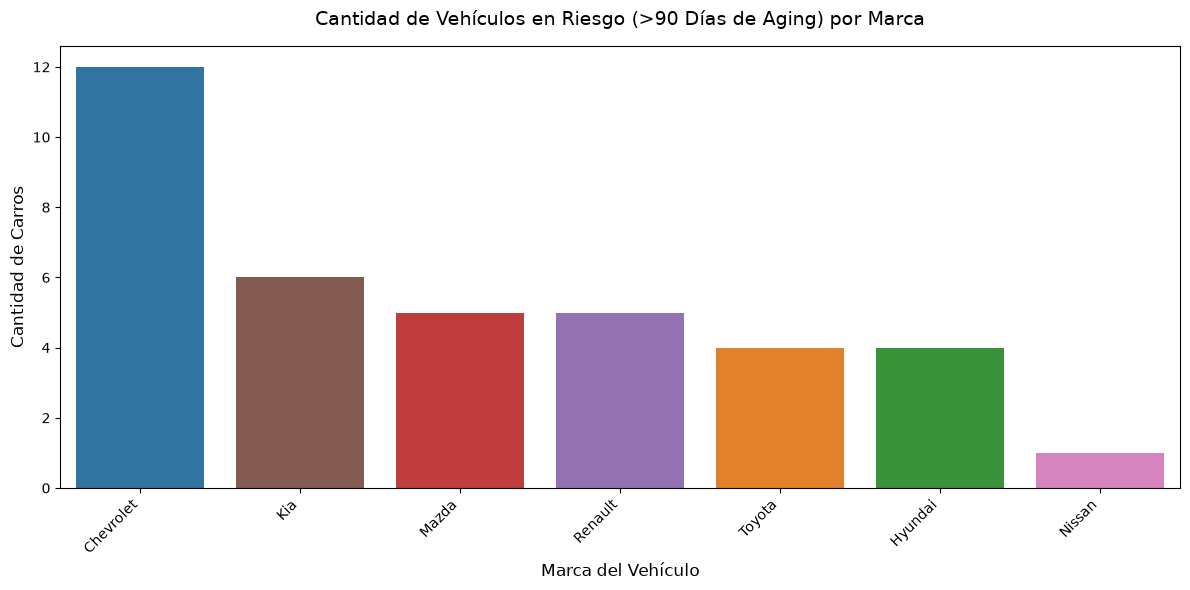

In [38]:
df_filtrado = df[df['Tramo_Aging'] == '>90 días']
orden_marcas = df_filtrado['Marca'].value_counts().index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_filtrado, 
    x='Marca', 
    order=orden_marcas,
    hue='Marca'
)
plt.title('Cantidad de Vehículos en Riesgo (>90 Días de Aging) por Marca', fontsize=14, pad=15)
plt.xlabel('Marca del Vehículo', fontsize=12)
plt.ylabel('Cantidad de Carros', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotamos las marcas para que no se pisen
plt.tight_layout()
plt.show()


## Síntesis Ejecutiva
A continuación, se presentan las conclusiones más importantes para el negocio producto del EDA

In [44]:
df_noadj = df[df['Estado_Subasta']!="Vendido"]
total_costo = round(df_noadj['Holding_Cost_COP'].sum())
print("\nMillones de COP que se pierden actualmente por el costo de tenencia acumulado en el inventario no adjudicado.:")
print(f"$ {total_costo:,}".replace(",", "."))


Millones de COP que se pierden actualmente por el costo de tenencia acumulado en el inventario no adjudicado.:
$ 169.454.624


In [45]:
df_noadj = df[df['Estado_Subasta']!="Vendido"]
total_vehículos = round(df_noadj['Holding_Cost_COP'].count())
print("\n La cantidad de vehículos que generan el costo de tenencia acumulado es:")
print(f"{total_vehículos}")


 La cantidad de vehículos que generan el costo de tenencia acumulado es:
97
